# Introducción a Matplotlib para Visión Artificial

Máster en Inteligencia Artificial, Universidad de Murcia, curso 2026/27.

Este notebook funciona en CPU tanto en Jupyter local como en Google Colab. Para
ejecución local se utiliza el entorno descrito en `README.md` y
`requirements-base.txt`. El último ejemplo necesita el ejecutable FFmpeg. 

Contenido basado en colección de notebooks del libro _"Hands on Machine Learning with Scikit-learn and Tensorflow"_ de Aurelien Geron ([enlace](https://machine-learning-apps.github.io/hands-on-ml2/)).

In [1]:
import platform
import sys

try:
    import google.colab  # type: ignore[import-not-found]
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Entorno:", "Google Colab" if IN_COLAB else "Jupyter local")
print("Python:", platform.python_version())

Entorno: Jupyter local
Python: 3.11.11


**Herramientas - matplotlib**

*Este notebook muestra cómo usar la biblioteca matplotlib para dibujar gráficos atractivos.*

# Índice
 <p><div class="lev1"><a href="#Plotting-your-first-graph"><span class="toc-item-num">1&nbsp;&nbsp;</span>Dibujar tu primer gráfico</a></div><div class="lev1"><a href="#Line-style-and-color"><span class="toc-item-num">2&nbsp;&nbsp;</span>Estilo y color de línea</a></div><div class="lev1"><a href="#Saving-a-figure"><span class="toc-item-num">3&nbsp;&nbsp;</span>Guardar una figura</a></div><div class="lev1"><a href="#Subplots"><span class="toc-item-num">4&nbsp;&nbsp;</span>Subgráficos</a></div><div class="lev1"><a href="#Multiple-figures"><span class="toc-item-num">5&nbsp;&nbsp;</span>Varias figuras</a></div><div class="lev1"><a href="#Pyplot's-state-machine:-implicit-vs-explicit"><span class="toc-item-num">6&nbsp;&nbsp;</span>La máquina de estados de Pyplot: implícito <em>frente a</em> explícito</a></div><div class="lev1"><a href="#Pylab-vs-Pyplot-vs-Matplotlib"><span class="toc-item-num">7&nbsp;&nbsp;</span>Pylab <em>frente a</em> Pyplot <em>frente a</em> Matplotlib</a></div><div class="lev1"><a href="#Drawing-text"><span class="toc-item-num">8&nbsp;&nbsp;</span>Dibujar texto</a></div><div class="lev1"><a href="#Legends"><span class="toc-item-num">9&nbsp;&nbsp;</span>Leyendas</a></div><div class="lev1"><a href="#Non-linear-scales"><span class="toc-item-num">10&nbsp;&nbsp;</span>Escalas no lineales</a></div><div class="lev1"><a href="#Ticks-and-tickers"><span class="toc-item-num">11&nbsp;&nbsp;</span>Marcas y tickers</a></div><div class="lev1"><a href="#Polar-projection"><span class="toc-item-num">12&nbsp;&nbsp;</span>Proyección polar</a></div><div class="lev1"><a href="#3D-projection"><span class="toc-item-num">13&nbsp;&nbsp;</span>Proyección 3D</a></div><div class="lev1"><a href="#Scatter-plot"><span class="toc-item-num">14&nbsp;&nbsp;</span>Diagrama de dispersión</a></div><div class="lev1"><a href="#Lines"><span class="toc-item-num">15&nbsp;&nbsp;</span>Líneas</a></div><div class="lev1"><a href="#Histograms"><span class="toc-item-num">16&nbsp;&nbsp;</span>Histogramas</a></div><div class="lev1"><a href="#Images"><span class="toc-item-num">17&nbsp;&nbsp;</span>Imágenes</a></div><div class="lev1"><a href="#Animations"><span class="toc-item-num">18&nbsp;&nbsp;</span>Animaciones</a></div><div class="lev1"><a href="#Saving-animations-to-video-files"><span class="toc-item-num">19&nbsp;&nbsp;</span>Guardar animaciones en archivos de vídeo</a></div><div class="lev1"><a href="#What-next?"><span class="toc-item-num">20&nbsp;&nbsp;</span>¿Y ahora qué?</a></div>

# Dibujar tu primer gráfico

Primero tenemos que importar la biblioteca `matplotlib`.

In [2]:
import matplotlib

Matplotlib puede generar gráficos usando varias bibliotecas gráficas de backend, como Tk, wxPython, etc. Cuando se ejecuta Python desde la línea de comandos, los gráficos se muestran normalmente en una ventana separada. En un notebook de Jupyter, podemos mostrar los gráficos dentro del propio notebook ejecutando el comando mágico `%matplotlib inline`.

In [3]:
%matplotlib inline
# matplotlib.use("TKAgg")  # usa esto en tu programa si quieres usar Tk como backend gráfico.


¡Ahora vamos a dibujar nuestro primer gráfico! :)

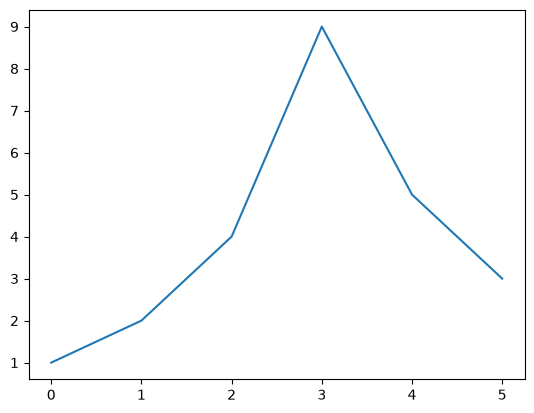

In [4]:
import matplotlib.pyplot as plt
plt.plot([1, 2, 4, 9, 5, 3])
plt.show()

Sí, es tan sencillo como llamar a la función `plot` con algunos datos y después llamar a la función `show`.

Si a la función `plot` se le da un único array de datos, lo usará como coordenadas del eje vertical y simplemente usará el índice de cada dato en el array como coordenada horizontal.
También puedes proporcionar dos arrays: uno para el eje horizontal `x` y el segundo para el eje vertical `y`:

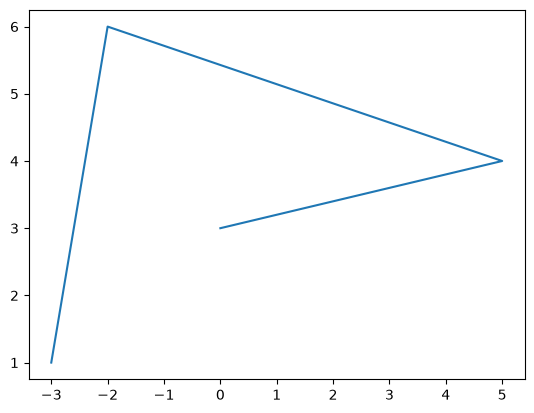

In [5]:
plt.plot([-3, -2, 5, 0], [1, 6, 4, 3])
plt.show()

Los ejes se ajustan automáticamente a la extensión de los datos. Queremos darle al gráfico un poco más de margen, así que llamemos a la función `axis` para cambiar la extensión de cada eje `[xmin, xmax, ymin, ymax]`.

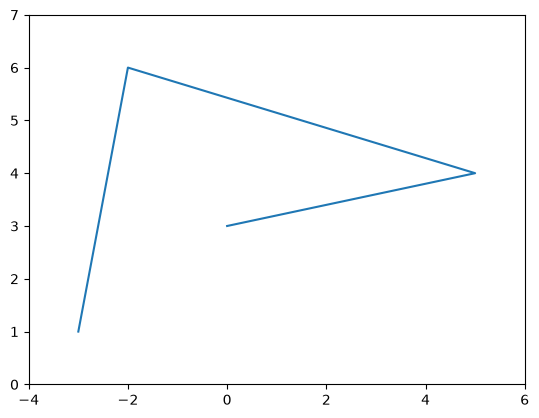

In [6]:
plt.plot([-3, -2, 5, 0], [1, 6, 4, 3])
plt.axis([-4, 6, 0, 7])
plt.show()

Ahora vamos a dibujar una función matemática. Usamos la función `linspace` de NumPy para crear un array `x` que contiene 500 números en coma flotante de -2 a 2; después creamos un segundo array `y` calculado como el cuadrado de `x` (para aprender sobre NumPy, lee el tutorial de NumPy en el correspondiente notebook compañero en el Aula Virtual.

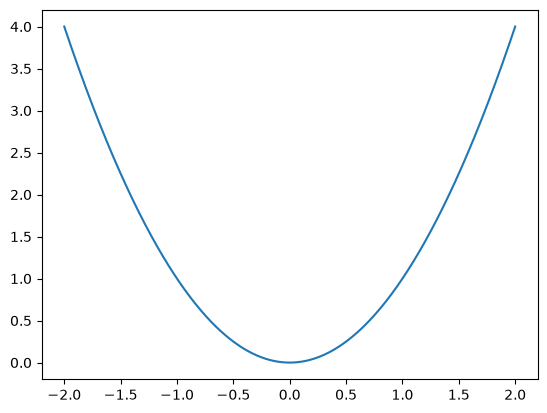

In [7]:
import numpy as np
x = np.linspace(-2, 2, 500)
y = x**2

plt.plot(x, y)
plt.show()

Esto queda un poco seco; añadamos un título, etiquetas para x e y, y dibujemos una rejilla.

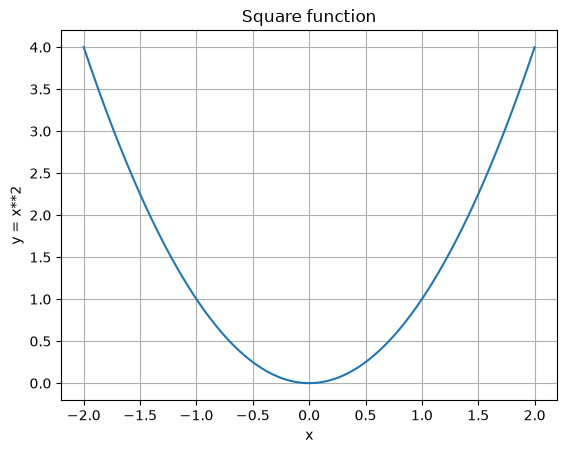

In [8]:
plt.plot(x, y)
plt.title("Square function")
plt.xlabel("x")
plt.ylabel("y = x**2")
plt.grid(True)
plt.show()

# Estilo y color de línea

Por defecto, matplotlib dibuja una línea entre puntos consecutivos.

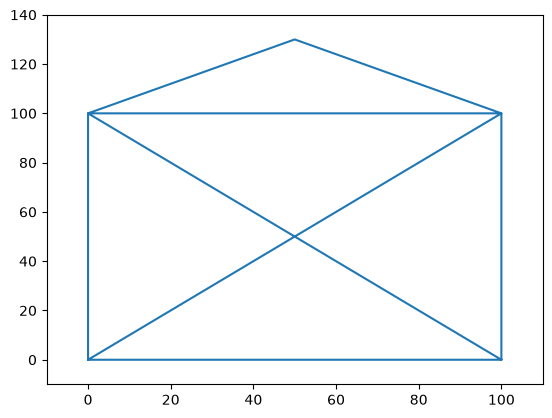

In [9]:
plt.plot([0, 100, 100, 0, 0, 100, 50, 0, 100], [0, 0, 100, 100, 0, 100, 130, 100, 0])
plt.axis([-10, 110, -10, 140])
plt.show()

Puedes pasar un tercer argumento para cambiar el estilo y el color de la línea.
Por ejemplo, `"g--"` significa "línea verde discontinua".

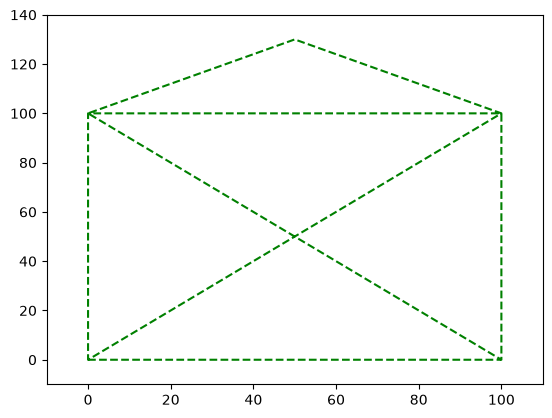

In [10]:
plt.plot([0, 100, 100, 0, 0, 100, 50, 0, 100], [0, 0, 100, 100, 0, 100, 130, 100, 0], "g--")
plt.axis([-10, 110, -10, 140])
plt.show()

Puedes dibujar varias líneas en un mismo gráfico de forma muy sencilla: basta con pasar `x1, y1, [style1], x2, y2, [style2], ...`

Por ejemplo:

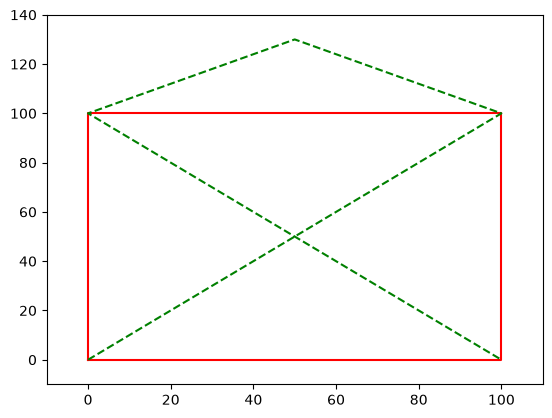

In [11]:
plt.plot([0, 100, 100, 0, 0], [0, 0, 100, 100, 0], "r-", [0, 100, 50, 0, 100], [0, 100, 130, 100, 0], "g--")
plt.axis([-10, 110, -10, 140])
plt.show()

O simplemente llamar a `plot` varias veces antes de llamar a `show`.

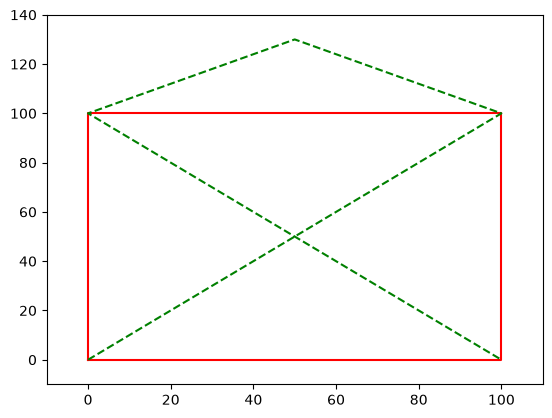

In [12]:
plt.plot([0, 100, 100, 0, 0], [0, 0, 100, 100, 0], "r-")
plt.plot([0, 100, 50, 0, 100], [0, 100, 130, 100, 0], "g--")
plt.axis([-10, 110, -10, 140])
plt.show()

Puedes dibujar puntos simples en lugar de líneas. Aquí tienes un ejemplo con trazos verdes, línea roja de puntos y triángulos azules.
Consulta [la documentación](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) para ver la lista completa de opciones de estilo y color.

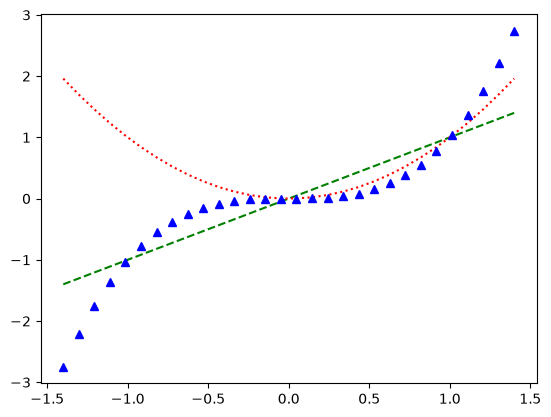

In [13]:
x = np.linspace(-1.4, 1.4, 30)
plt.plot(x, x, 'g--', x, x**2, 'r:', x, x**3, 'b^')
plt.show()

La función `plot` devuelve una lista de objetos `Line2D` (uno por cada línea). Puedes establecer atributos adicionales en estas líneas, como el ancho de línea, el estilo de guiones o el nivel alfa. Consulta la lista completa de atributos en [la documentación](http://matplotlib.org/users/pyplot_tutorial.html#controlling-line-properties).

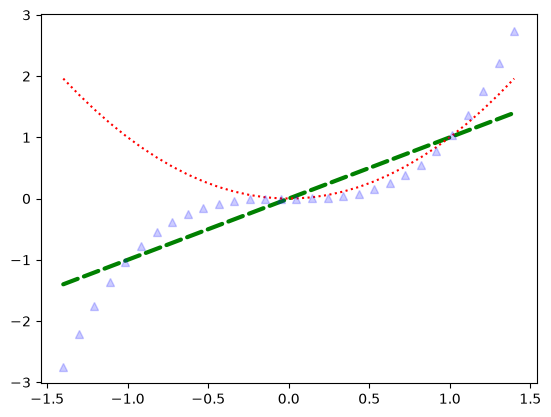

In [14]:
x = np.linspace(-1.4, 1.4, 30)
line1, line2, line3 = plt.plot(x, x, 'g--', x, x**2, 'r:', x, x**3, 'b^')
line1.set_linewidth(3.0)
line1.set_dash_capstyle("round")
line3.set_alpha(0.2)
plt.show()

# Guardar una figura
Guardar una figura en disco es tan sencillo como llamar a [`savefig`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html) con el nombre del archivo (o con un objeto archivo). Los formatos de imagen disponibles dependen del backend gráfico que uses.

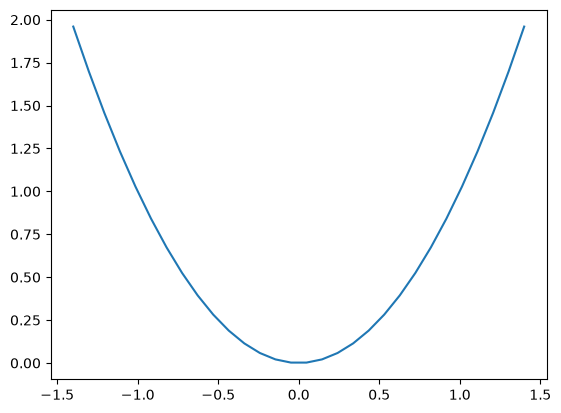

In [15]:
x = np.linspace(-1.4, 1.4, 30)
plt.plot(x, x**2)
plt.savefig("my_square_function.png", transparent=True)

# Subplots
Una figura de matplotlib puede contener varios subgráficos. Estos subgráficos se organizan en una rejilla. Para crear un subgráfico, basta con llamar a la función `subplot` e indicar el número de filas y columnas de la figura, y el índice del subgráfico sobre el que quieres dibujar (empezando en 1, luego de izquierda a derecha y de arriba abajo). Observa que pyplot lleva la cuenta del subgráfico activo en cada momento (del que puedes obtener una referencia llamando a `plt.gca()`), así que cuando llamas a la función `plot`, dibuja sobre el subgráfico *activo*.


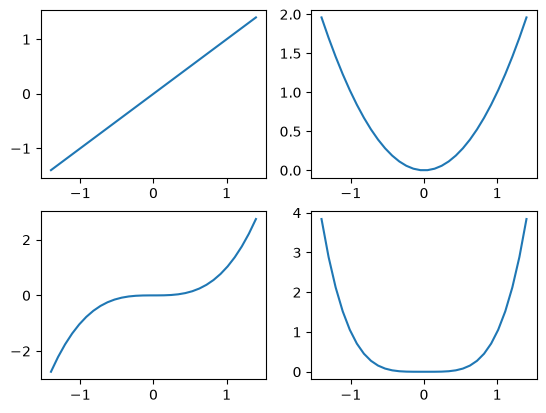

In [16]:
x = np.linspace(-1.4, 1.4, 30)
plt.subplot(2, 2, 1)  # 2 filas, 2 columnas, 1.er subgráfico = arriba izquierda
plt.plot(x, x)
plt.subplot(2, 2, 2)  # 2 filas, 2 columnas, 2.º subgráfico = arriba derecha
plt.plot(x, x**2)
plt.subplot(2, 2, 3)  # 2 filas, 2 columnas, 3.er subgráfico = abajo izquierda
plt.plot(x, x**3)
plt.subplot(2, 2, 4)  # 2 filas, 2 columnas, 4.º subgráfico = abajo derecha
plt.plot(x, x**4)
plt.show()

* Observa que `subplot(223)` es una abreviatura de `subplot(2, 2, 3)`.

Es fácil crear subgráficos que se extienden por varias celdas de la rejilla, así:

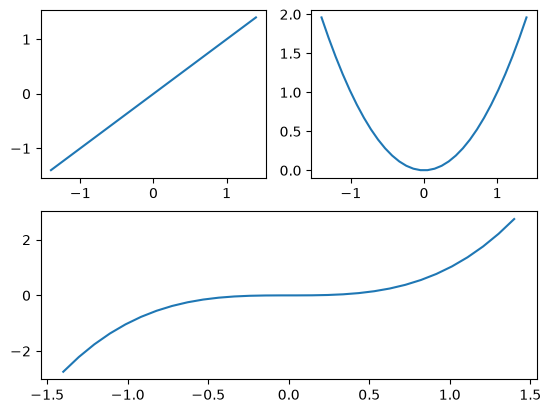

In [17]:
plt.subplot(2, 2, 1)  # 2 filas, 2 columnas, 1.er subgráfico = arriba izquierda
plt.plot(x, x)
plt.subplot(2, 2, 2)  # 2 filas, 2 columnas, 2.º subgráfico = arriba derecha
plt.plot(x, x**2)
plt.subplot(2, 1, 2)  # 2 filas, *1* columna, 2.º subgráfico = abajo
plt.plot(x, x**3)
plt.show()

Si necesitas un posicionamiento de subgráficos más complejo, puedes usar `subplot2grid` en lugar de `subplot`. Indicas el número de filas y columnas de la rejilla, luego la posición de tu subgráfico dentro de esa rejilla (arriba-izquierda = (0,0)) y, opcionalmente, cuántas filas y/o columnas ocupa. Por ejemplo:

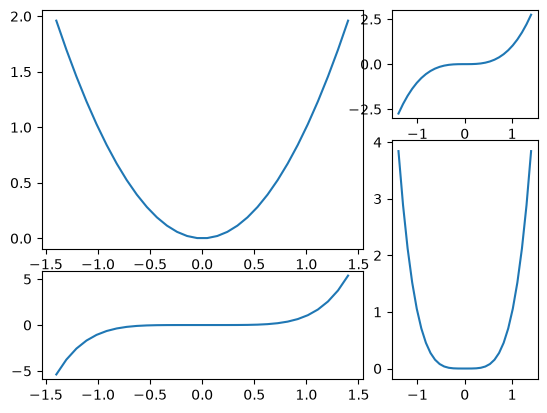

In [18]:
plt.subplot2grid((3,3), (0, 0), rowspan=2, colspan=2)
plt.plot(x, x**2)
plt.subplot2grid((3,3), (0, 2))
plt.plot(x, x**3)
plt.subplot2grid((3,3), (1, 2), rowspan=2)
plt.plot(x, x**4)
plt.subplot2grid((3,3), (2, 0), colspan=2)
plt.plot(x, x**5)
plt.show()

Si necesitas todavía más flexibilidad en la colocación de subgráficos, consulta la [documentación de GridSpec](https://matplotlib.org/3.0.2/tutorials/intermediate/gridspec.html).

# Varias figuras
También es posible dibujar varias figuras. Cada figura puede contener uno o más subgráficos. Por defecto, matplotlib crea `figure(1)` automáticamente. Cuando cambias de figura, pyplot lleva la cuenta de la figura activa en cada momento (de la que puedes obtener una referencia llamando a `plt.gcf()`), y el subgráfico activo de esa figura pasa a ser el subgráfico actual.

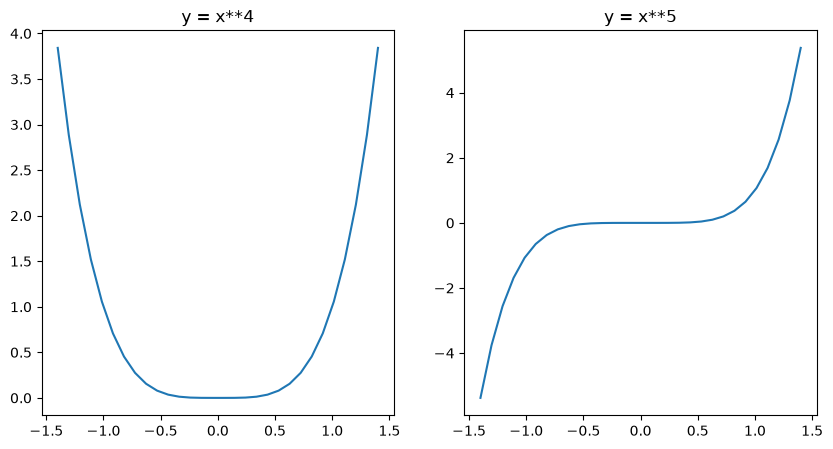

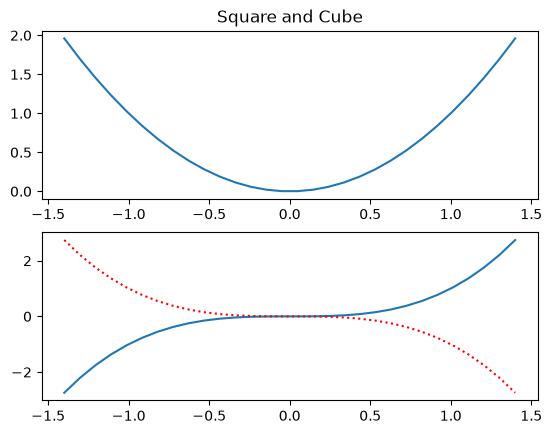

In [19]:
x = np.linspace(-1.4, 1.4, 30)

plt.figure(1)
plt.subplot(211)
plt.plot(x, x**2)
plt.title("Square and Cube")
plt.subplot(212)
plt.plot(x, x**3)

plt.figure(2, figsize=(10, 5))
plt.subplot(121)
plt.plot(x, x**4)
plt.title("y = x**4")
plt.subplot(122)
plt.plot(x, x**5)
plt.title("y = x**5")

plt.figure(1)      # vuelta a la figura 1, el subgráfico actual es 212 (abajo)
plt.plot(x, -x**3, "r:")

plt.show()

# La máquina de estados de Pyplot: implícito *frente a* explícito
Hasta ahora hemos usado la máquina de estados de Pyplot, que lleva la cuenta del subgráfico activo en cada momento. Cada vez que llamas a la función `plot`, pyplot simplemente dibuja sobre el subgráfico activo. También hace algo más de "magia", como crear automáticamente una figura y un subgráfico cuando llamas a `plot`, si todavía no existen. Esta magia es cómoda en un entorno interactivo (como Jupyter).

Pero cuando escribes un programa, *explícito es mejor que implícito*. El código explícito suele ser más fácil de depurar y mantener, y si no me crees basta con leer la segunda regla del Zen de Python:

In [20]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


Afortunadamente, Pyplot permite ignorar por completo la máquina de estados, para que puedas escribir código explícito y elegante. Simplemente llama a la función `subplots` y usa el objeto figura y la lista de objetos eje que se devuelven. ¡Se acabó la magia! Por ejemplo:

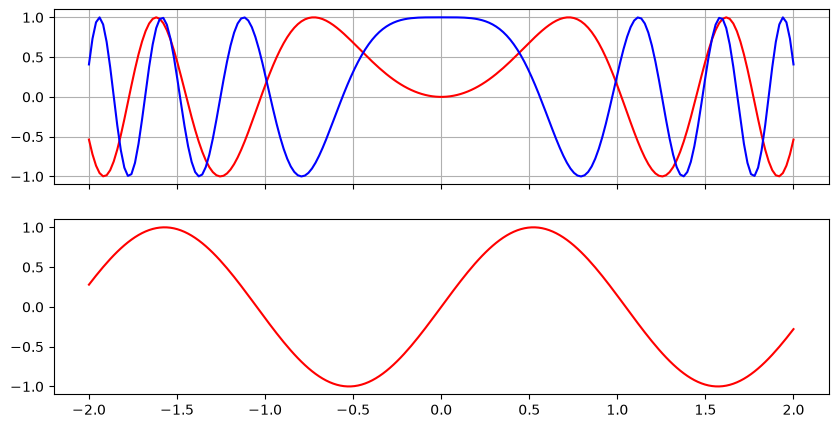

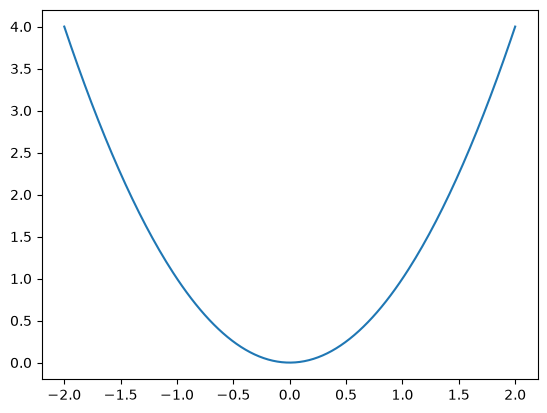

In [21]:
x = np.linspace(-2, 2, 200)
fig1, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True)
fig1.set_size_inches(10,5)
line1, line2 = ax_top.plot(x, np.sin(3*x**2), "r-", x, np.cos(5*x**2), "b-")
line3, = ax_bottom.plot(x, np.sin(3*x), "r-")
ax_top.grid(True)

fig2, ax = plt.subplots(1, 1)
ax.plot(x, x**2)
plt.show()

Por coherencia, seguiremos usando la máquina de estados de pyplot en el resto de este tutorial, pero recomendamos usar la interfaz orientada a objetos en tus programas.

# Pylab *frente a* Pyplot *frente a* Matplotlib

Hay cierta confusión sobre la relación entre pylab, pyplot y matplotlib. Es sencillo: matplotlib es la biblioteca completa; lo contiene todo, incluidos pylab y pyplot.

Pyplot proporciona varias herramientas para dibujar gráficos, incluida la interfaz de máquina de estados hacia la biblioteca de dibujo orientada a objetos subyacente.

Pylab es un módulo de conveniencia que importa matplotlib.pyplot y NumPy en un único espacio de nombres. Encontrarás muchos ejemplos que usan pylab, pero ya no se recomienda (porque las importaciones *explícitas* son mejores que las *implícitas*).

# Dibujar texto
Puedes llamar a `text` para añadir texto en cualquier posición del gráfico. Solo tienes que indicar las coordenadas horizontal y vertical y el texto, y opcionalmente algunos atributos adicionales. Cualquier texto en matplotlib puede contener expresiones de ecuaciones TeX; consulta [la documentación](http://matplotlib.org/users/mathtext.html) para más detalles.

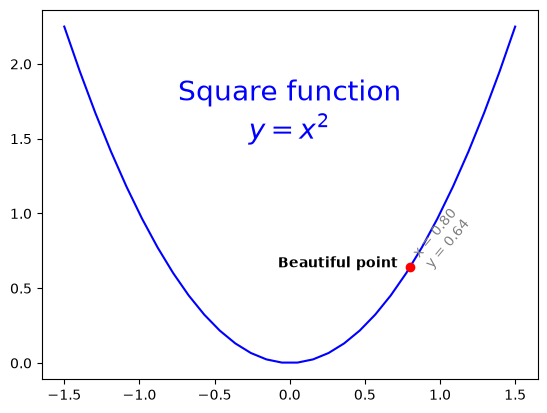

In [22]:
x = np.linspace(-1.5, 1.5, 30)
px = 0.8
py = px**2

plt.plot(x, x**2, "b-", px, py, "ro")

plt.text(0, 1.5, "Square function\n$y = x^2$", fontsize=20, color='blue', horizontalalignment="center")
plt.text(px - 0.08, py, "Beautiful point", ha="right", weight="bold")
plt.text(px, py, "x = %0.2f\ny = %0.2f"%(px, py), rotation=50, color='gray')

plt.show()

* Nota: `ha` es un alias de `horizontalalignment`

Para ver más propiedades de texto, visita [la documentación](https://matplotlib.org/stable/users/explain/text/text_props.html).

Es bastante frecuente anotar elementos de un gráfico, como el bonito punto anterior. La función `annotate` lo facilita: basta con indicar la posición del punto de interés y la posición del texto, además de algunos atributos opcionales para el texto y la flecha.

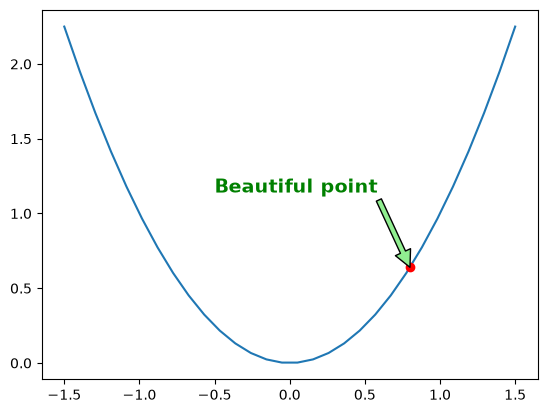

In [23]:
plt.plot(x, x**2, px, py, "ro")
plt.annotate("Beautiful point", xy=(px, py), xytext=(px-1.3,py+0.5),
                           color="green", weight="bold", fontsize=14,
                           arrowprops={"facecolor": "lightgreen"})
plt.show()

También puedes añadir un recuadro alrededor de tu texto usando el atributo `bbox`:

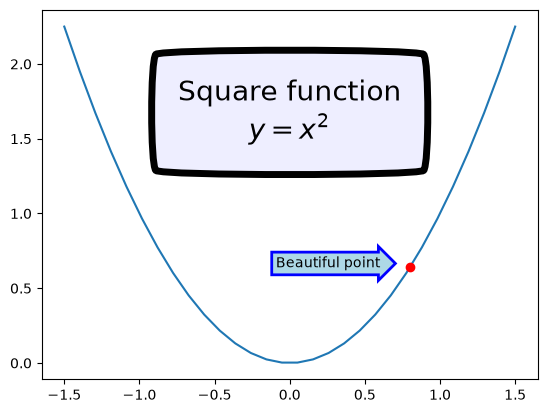

In [24]:
plt.plot(x, x**2, px, py, "ro")

bbox_props = dict(boxstyle="rarrow,pad=0.3", ec="b", lw=2, fc="lightblue")
plt.text(px-0.2, py, "Beautiful point", bbox=bbox_props, ha="right")

bbox_props = dict(boxstyle="round4,pad=1,rounding_size=0.2", ec="black", fc="#EEEEFF", lw=5)
plt.text(0, 1.5, "Square function\n$y = x^2$", fontsize=20, color='black', ha="center", bbox=bbox_props)

plt.show()

Solo por diversión, si quieres un gráfico de estilo [xkcd](https://xkcd.com), dibuja dentro de una sección `with plt.xkcd()`:

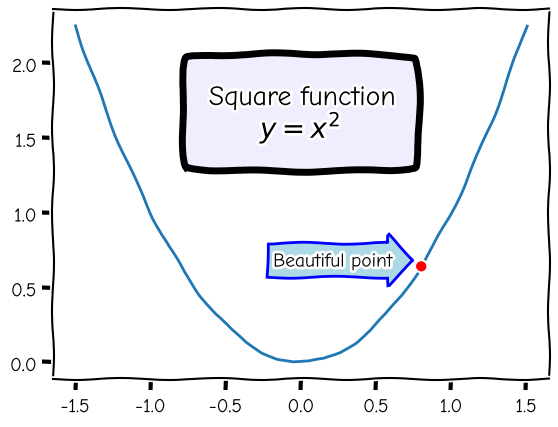

In [25]:
with plt.xkcd(): 
    plt.rcParams["font.family"] = ["Comic Neue"]
    plt.plot(x, x**2, px, py, "ro")

    bbox_props = dict(boxstyle="rarrow,pad=0.3", ec="b", lw=2, fc="lightblue")
    plt.text(px-0.2, py, "Beautiful point", bbox=bbox_props, ha="right")

    bbox_props = dict(boxstyle="round4,pad=1,rounding_size=0.2", ec="black", fc="#EEEEFF", lw=5)
    plt.text(0, 1.5, "Square function\n$y = x^2$", fontsize=20, color='black', ha="center", bbox=bbox_props)

    plt.show()

# Leyendas
La forma más sencilla de añadir una leyenda es definir una etiqueta en todas las líneas y luego llamar a la función `legend`.

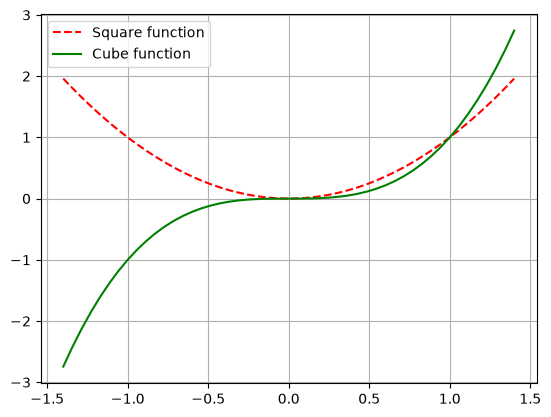

In [26]:
x = np.linspace(-1.4, 1.4, 50)
plt.plot(x, x**2, "r--", label="Square function")
plt.plot(x, x**3, "g-", label="Cube function")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Escalas no lineales
Matplotlib admite escalas no lineales, como escalas logarítmicas o logit.

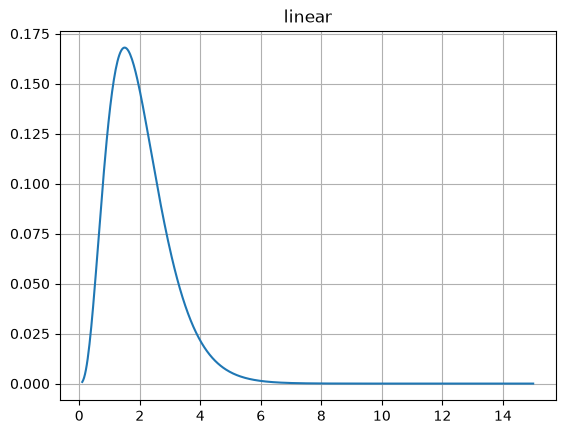

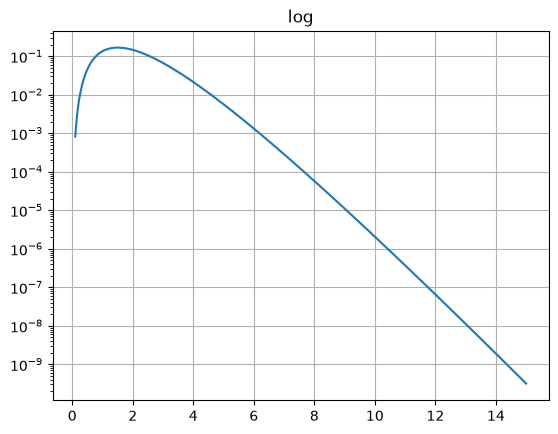

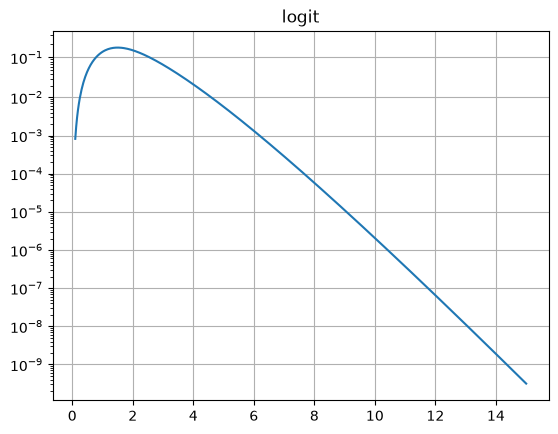

In [27]:
x = np.linspace(0.1, 15, 500)
y = x**3/np.exp(2*x)

plt.figure(1)
plt.plot(x, y)
plt.yscale('linear')
plt.title('linear')
plt.grid(True)

plt.figure(2)
plt.plot(x, y)
plt.yscale('log')
plt.title('log')
plt.grid(True)

plt.figure(3)
plt.plot(x, y)
plt.yscale('logit')
plt.title('logit')
plt.grid(True)

plt.show()

# Marcas y tickers
Los ejes tienen pequeñas marcas llamadas "ticks". Para ser precisos, los "ticks" son las *posiciones* de las marcas (por ejemplo, (-1, 0, 1)), las "tick lines" son las pequeñas líneas dibujadas en esas posiciones, las "tick labels" son las etiquetas dibujadas junto a esas líneas, y los "tickers" son objetos capaces de decidir dónde colocar las marcas. Los tickers por defecto suelen hacer un trabajo bastante bueno colocando entre unas 5 y 8 marcas a una distancia razonable entre sí.

Pero a veces necesitas más control (por ejemplo, hay demasiadas etiquetas de marcas en el gráfico logit anterior). Afortunadamente, matplotlib te da control total sobre las marcas. Incluso puedes activar marcas menores.



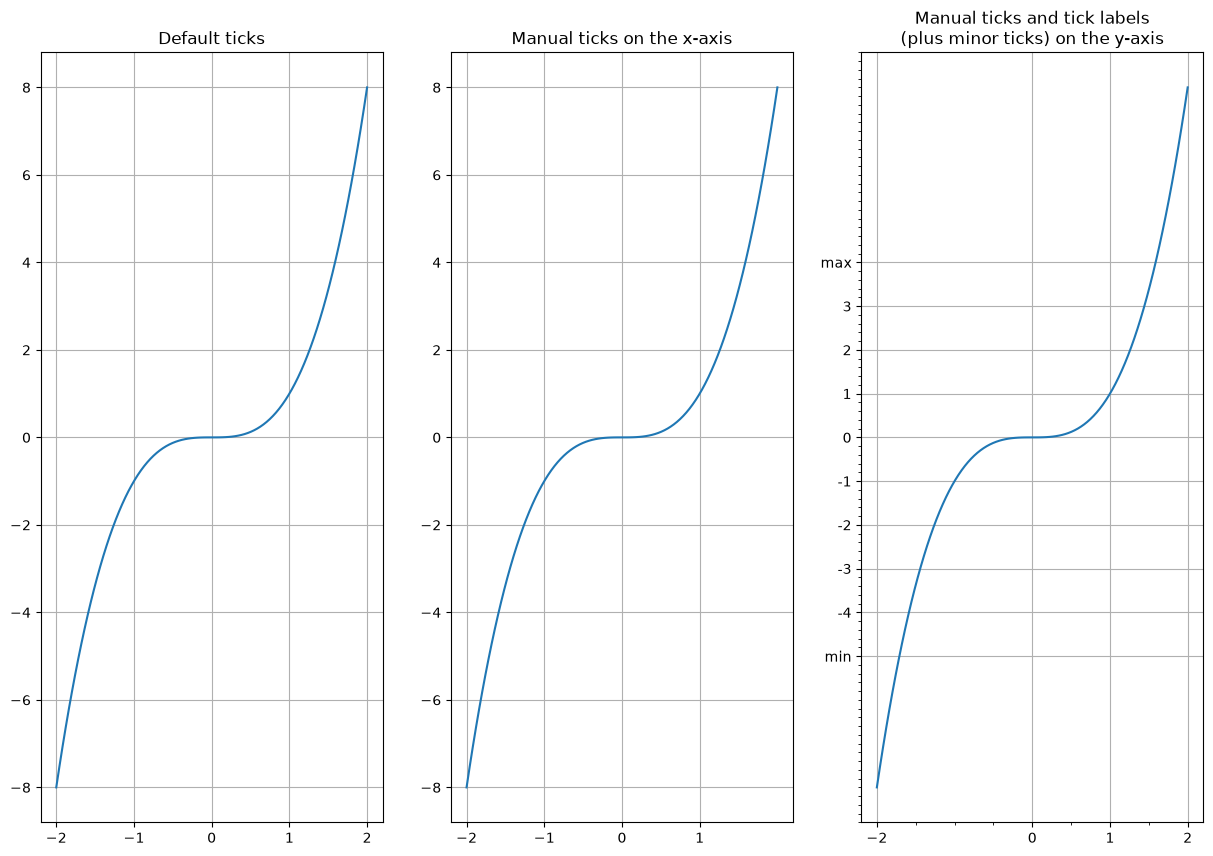

In [28]:
x = np.linspace(-2, 2, 100)

plt.figure(1, figsize=(15,10))
plt.subplot(131)
plt.plot(x, x**3)
plt.grid(True)
plt.title("Default ticks")

ax = plt.subplot(132)
plt.plot(x, x**3)
ax.xaxis.set_ticks(np.arange(-2, 2, 1))
plt.grid(True)
plt.title("Manual ticks on the x-axis")

ax = plt.subplot(133)
plt.plot(x, x**3)
plt.minorticks_on()
ax.tick_params(axis='x', which='minor', bottom='off')
ax.xaxis.set_ticks([-2, 0, 1, 2])
ax.yaxis.set_ticks(np.arange(-5, 5, 1))
ax.yaxis.set_ticklabels(["min", -4, -3, -2, -1, 0, 1, 2, 3, "max"])
plt.title("Manual ticks and tick labels\n(plus minor ticks) on the y-axis")


plt.grid(True)

plt.show()

# Proyección polar
Dibujar un gráfico polar es tan sencillo como establecer el atributo `projection` a `"polar"` al crear el subplot.

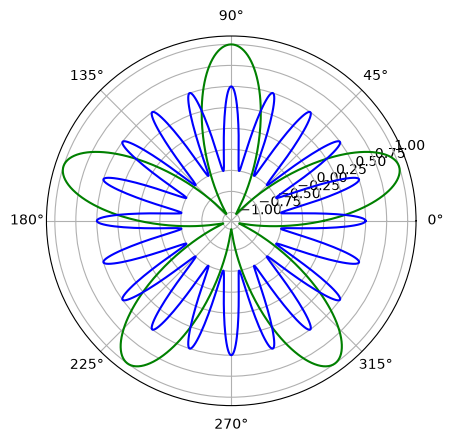

In [29]:
radius = 1
theta = np.linspace(0, 2*np.pi*radius, 1000)

plt.subplot(111, projection='polar')
plt.plot(theta, np.sin(5*theta), "g-")
plt.plot(theta, 0.5*np.cos(20*theta), "b-")
plt.show()

# Proyección 3D

Dibujar gráficos 3D es bastante directo. Tienes que importar `Axes3D`, que registra la proyección `"3d"`. Después crea un subplot estableciendo `projection` a `"3d"`. Esto devuelve un objeto `Axes3DSubplot`, que puedes usar para llamar a `plot_surface`, pasando las coordenadas x, y y z, además de atributos opcionales.

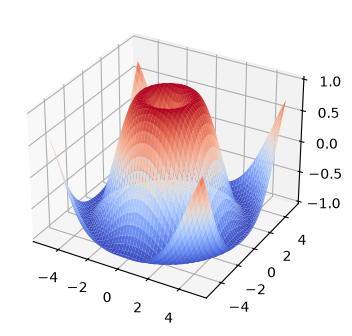

In [30]:
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

figure = plt.figure(1, figsize = (12, 4))
subplot3d = plt.subplot(111, projection='3d')
surface = subplot3d.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=matplotlib.cm.coolwarm, linewidth=0.1)
plt.show()


Otra forma de visualizar estos mismos datos es *vía* un gráfico de contornos.

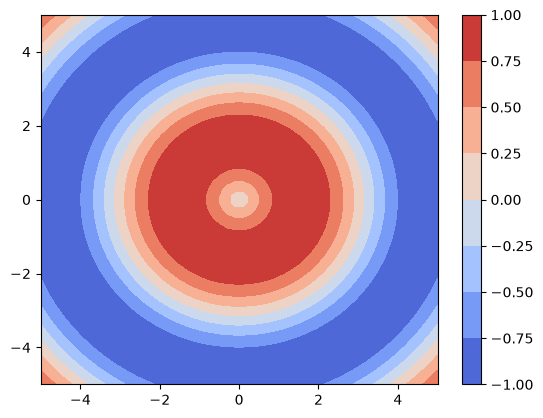

In [31]:
plt.contourf(X, Y, Z, cmap=matplotlib.cm.coolwarm)
plt.colorbar()
plt.show()

# Diagrama de dispersión

Para dibujar un diagrama de dispersión, basta con proporcionar las coordenadas x e y de los puntos.

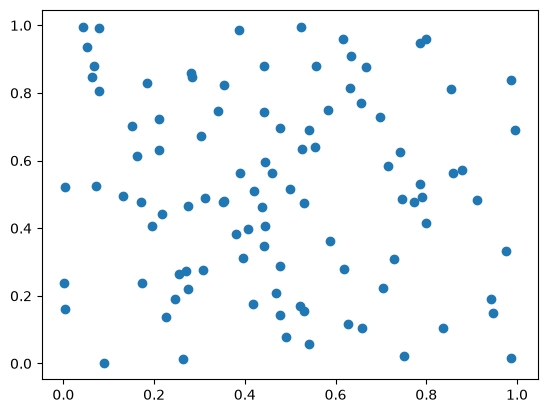

In [32]:
from numpy.random import rand
x, y = rand(2, 100)
plt.scatter(x, y)
plt.show()

También puedes proporcionar opcionalmente la escala de cada punto.

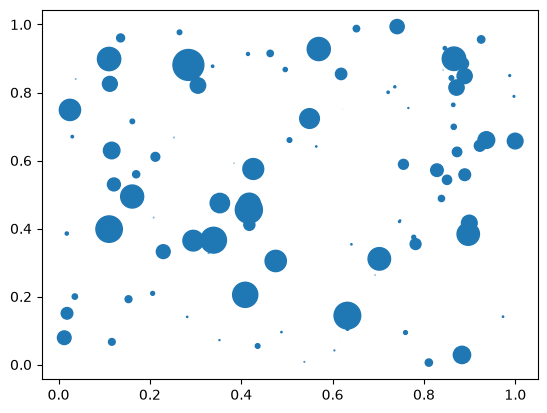

In [33]:
x, y, scale = rand(3, 100)
scale = 500 * scale ** 5
plt.scatter(x, y, s=scale)
plt.show()

Y, como de costumbre, hay otros muchos atributos que puedes establecer, como los colores de relleno y borde y el nivel alfa.

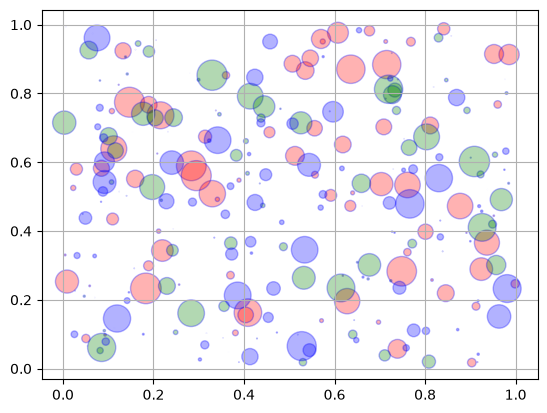

In [34]:
for color in ['red', 'green', 'blue']:
    n = 100
    x, y = rand(2, n)
    scale = 500.0 * rand(n) ** 5
    plt.scatter(x, y, s=scale, c=color, alpha=0.3, edgecolors='blue')

plt.grid(True)

plt.show()


# Líneas
Puedes dibujar líneas simplemente usando la función `plot`, como hemos hecho hasta ahora. Sin embargo, a menudo resulta cómodo crear una función auxiliar que dibuje una línea (aparentemente) infinita a través del gráfico, dada una pendiente y una ordenada en el origen. También puedes usar las funciones `hlines` y `vlines`, que dibujan segmentos de línea horizontales y verticales.
Por ejemplo:

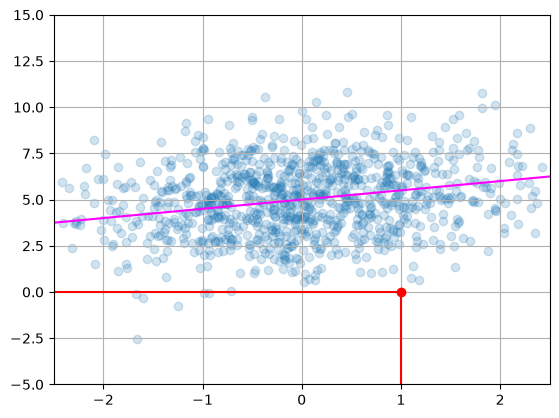

In [35]:
from numpy.random import randn

def plot_line(axis, slope, intercept, **kargs):
    xmin, xmax = axis.get_xlim()
    plt.plot([xmin, xmax], [xmin*slope+intercept, xmax*slope+intercept], **kargs)

x = randn(1000)
y = 0.5*x + 5 + randn(1000)*2
plt.axis([-2.5, 2.5, -5, 15])
plt.scatter(x, y, alpha=0.2)
plt.plot(1, 0, "ro")
plt.vlines(1, -5, 0, color="red")
plt.hlines(0, -2.5, 1, color="red")
plot_line(axis=plt.gca(), slope=0.5, intercept=5, color="magenta")
plt.grid(True)
plt.show()

# Histogramas

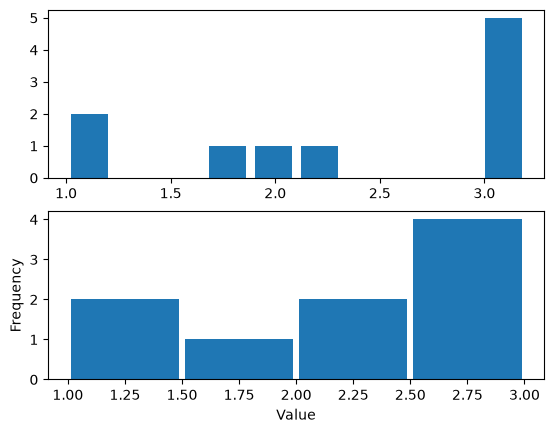

In [36]:
data = [1, 1.1, 1.8, 2, 2.1, 3.2, 3, 3, 3, 3]
plt.subplot(211)
plt.hist(data, bins = 10, rwidth=0.8)

plt.subplot(212)
plt.hist(data, bins = [1, 1.5, 2, 2.5, 3], rwidth=0.95)
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

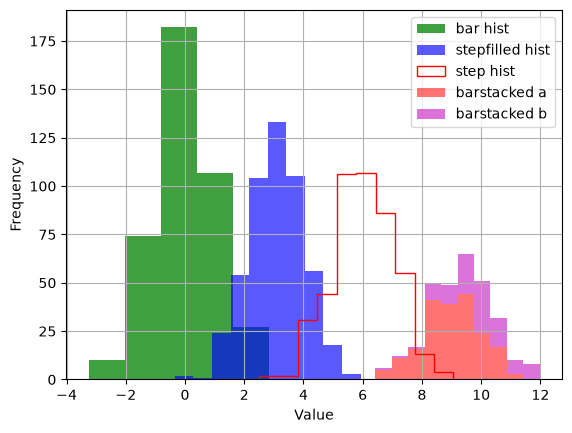

In [37]:
data1 = np.random.randn(400)
data2 = np.random.randn(500) + 3
data3 = np.random.randn(450) + 6
data4a = np.random.randn(200) + 9
data4b = np.random.randn(100) + 10

plt.hist(data1, bins=5, color='g', alpha=0.75, label='bar hist') # histtype='bar' por defecto
plt.hist(data2, color='b', alpha=0.65, histtype='stepfilled', label='stepfilled hist')
plt.hist(data3, color='r', histtype='step', label='step hist')
plt.hist((data4a, data4b), color=['r','m'], alpha=0.55, histtype='barstacked', label=('barstacked a', 'barstacked b'))

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# Imágenes
Leer, generar y dibujar imágenes en matplotlib es bastante directo.

Para leer una imagen, basta con importar el módulo `matplotlib.image` y llamar a su función `imread`, pasándole el nombre del archivo (o un objeto archivo). Esto devuelve los datos de la imagen como un array de NumPy. Probemos con la imagen `my_square_function.png` que guardamos antes.

In [38]:
import matplotlib.image as mpimg

img = mpimg.imread('my_square_function.png')
print(img.shape, img.dtype)

(480, 640, 4) float32


Hemos cargado una imagen de 288x432. Cada píxel está representado por un array de 4 elementos: niveles de rojo, verde, azul y alfa, almacenados como números en coma flotante de 32 bits entre 0 y 1. Ahora todo lo que tenemos que hacer es llamar a `imshow`:

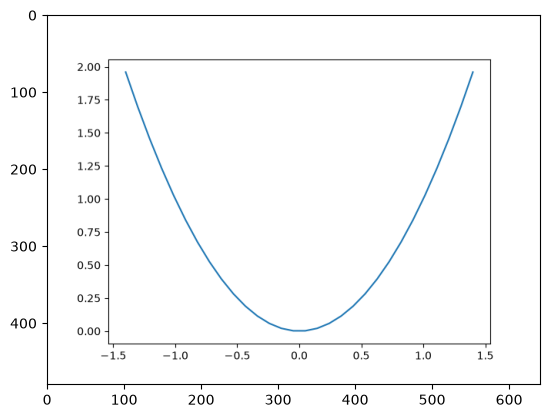

In [39]:
plt.imshow(img)
plt.show()

¡Tachán! Quizá quieras ocultar los ejes cuando estés mostrando una imagen:

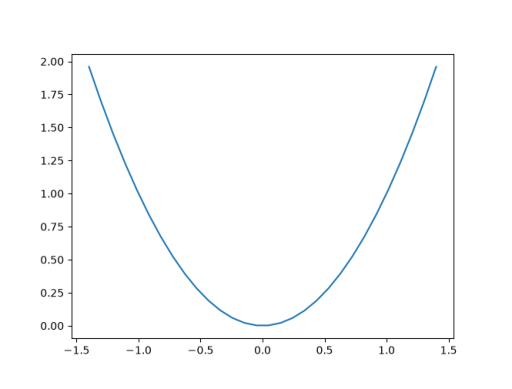

In [40]:
plt.imshow(img)
plt.axis('off')
plt.show()

Es igual de fácil generar tu propia imagen:

[[   0    1    2 ...   97   98   99]
 [ 100  101  102 ...  197  198  199]
 [ 200  201  202 ...  297  298  299]
 ...
 [9700 9701 9702 ... 9797 9798 9799]
 [9800 9801 9802 ... 9897 9898 9899]
 [9900 9901 9902 ... 9997 9998 9999]]


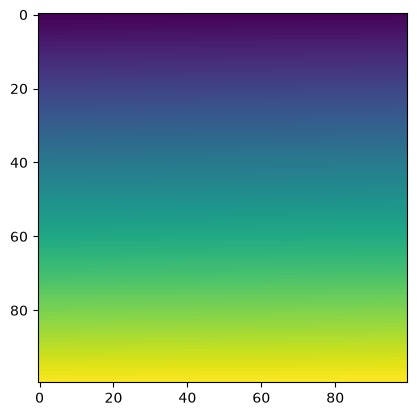

In [41]:
img = np.arange(100*100).reshape(100, 100)
print(img)
plt.imshow(img)
plt.show()

Como no proporcionamos niveles RGB, la función `imshow` asigna automáticamente los valores a un gradiente de color. Por defecto, el gradiente de color va del azul (para valores bajos) al rojo (para valores altos), pero puedes seleccionar otro mapa de colores. Por ejemplo:

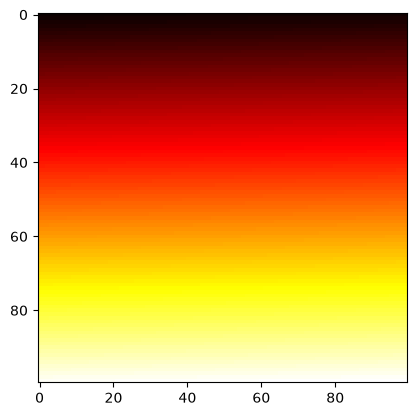

In [42]:
plt.imshow(img, cmap="hot")
plt.show()

También puedes generar directamente una imagen RGB:

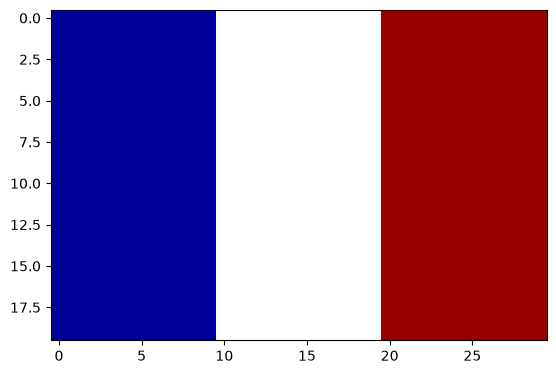

In [43]:
img = np.empty((20,30,3))
img[:, :10] = [0, 0, 0.6]
img[:, 10:20] = [1, 1, 1]
img[:, 20:] = [0.6, 0, 0]
plt.imshow(img)
plt.show()

Como el array `img` es bastante pequeño (20x30), cuando la función `imshow` lo muestra, agranda la imagen hasta el tamaño de la figura. Imagina que estiras la imagen original, dejando huecos entre los píxeles originales. ¿Cómo rellena `imshow` esos huecos? Por defecto, simplemente colorea cada píxel vacío usando el color del píxel no vacío más cercano. Esta técnica puede producir imágenes pixeladas. Si lo prefieres, puedes usar otro método de interpolación, como la [interpolación bilineal](https://en.wikipedia.org/wiki/Bilinear_interpolation), para rellenar los píxeles vacíos. Esto produce bordes borrosos, que pueden resultar más agradables en algunos casos:

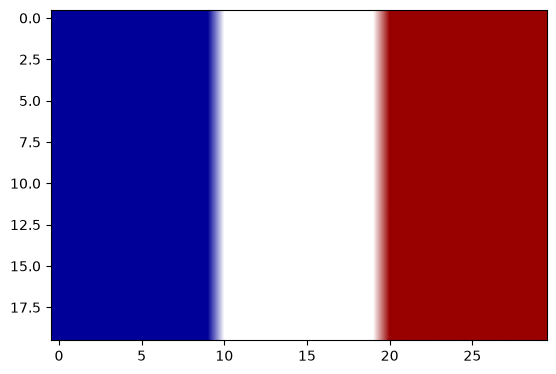

In [44]:
plt.imshow(img, interpolation="bilinear")
plt.show()

# Animaciones
Aunque matplotlib se usa sobre todo para generar imágenes, también es capaz de mostrar animaciones. Primero tienes que importar `matplotlib.animation`.

In [45]:
import matplotlib.animation as animation

En el ejemplo siguiente, empezamos creando puntos de datos; después creamos un gráfico vacío, definimos la función de actualización que se llamará en cada iteración de la animación y, por último, añadimos una animación al gráfico creando una instancia de `FuncAnimation`.

El constructor de `FuncAnimation` toma una figura, una función de actualización y argumentos opcionales. Especificamos que queremos una animación de 50 fotogramas, con 100 ms entre cada fotograma. En cada iteración, `FuncAnimation` llama a nuestra función de actualización y le pasa el número de fotograma `num` (de 0 a 49 en nuestro caso), seguido de los argumentos adicionales que especificamos con `fargs`.

Nuestra función de actualización simplemente establece los datos de la línea como los primeros `num` puntos de datos (de modo que los datos se van dibujando gradualmente) y, solo por diversión, añadimos además un pequeño número aleatorio a cada punto de datos para que la línea parezca ondular.

In [46]:
x = np.linspace(-1, 1, 100)
y = np.sin(x**2*25)
data = np.array([x, y])

fig = plt.figure()
line, = plt.plot([], [], "r-") # empieza con un gráfico vacío
plt.axis([-1.1, 1.1, -1.1, 1.1])
plt.plot([-0.5, 0.5], [0, 0], "b-", [0, 0], [-0.5, 0.5], "b-", 0, 0, "ro")
plt.grid(True)
plt.title("Marvelous animation")

# esta función se llamará en cada iteración
def update_line(num, data, line):
    line.set_data(data[..., :num] + np.random.rand(2, num) / 25)  # solo dibujamos los primeros `num` puntos de datos.
    return line,

line_ani = animation.FuncAnimation(fig, update_line, frames=50, fargs=(data, line), interval=100)
plt.close() # llama a close() para evitar mostrar el gráfico estático

A continuación, mostremos la animación. Una opción es convertirla a código HTML5 (usando una etiqueta `<video>`) y renderizar este código usando `IPython.display.HTML`:

In [47]:
from IPython.display import HTML

HTML(line_ani.to_html5_video())

Como alternativa, podemos mostrar la animación usando un pequeño y agradable widget interactivo HTML/Javascript:

In [48]:
HTML(line_ani.to_jshtml())

Puedes configurar Matplotlib para que use este widget por defecto al renderizar animaciones:

In [49]:
matplotlib.rc('animation', html='jshtml')

Después de eso, ya ni siquiera necesitas usar `IPython.display.HTML`:

In [50]:
animation.FuncAnimation(fig, update_line, frames=50, fargs=(data, line), interval=100)

**Advertencia:** si guardas el notebook junto con sus salidas, las animaciones ocuparán mucho espacio.

# Guardar animaciones en archivos de vídeo
Matplotlib se apoya en bibliotecas de terceros para escribir vídeos, como [FFMPEG](https://www.ffmpeg.org/) o [ImageMagick](https://imagemagick.org/). En este ejemplo usaremos FFMPEG, así que asegúrate de instalarlo primero. Para guardar la animación en formato GIF necesitarías ImageMagick.

In [51]:
from shutil import which

if which("ffmpeg") is None:
    raise RuntimeError(
        "No se encuentra FFmpeg. Consulta las instrucciones de instalación en README.md."
    )
print("FFmpeg disponible")

FFmpeg disponible


In [52]:
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
line_ani.save('my_wiggly_animation.mp4', writer=writer)

# ¿Y ahora qué?
Ahora conoces todos los fundamentos de matplotlib, pero hay muchas más opciones disponibles. La mejor forma de aprender más es visitar la [galería](https://matplotlib.org/stable/gallery/index.html), mirar las imágenes, elegir un gráfico que te interese, copiar el código en un notebook de Jupyter y trastear con él.